In [1]:
# Colab bootstrap — auto-clone repo on Google Colab, no-op locally
import os, sys, subprocess

REPO = "https://github.com/jongmoonha/AI-PHM_Graduate.git"
DIR  = "AI-PHM_Graduate"

try:
    import google.colab  # type: ignore
    target = '/content/' + DIR
    if not os.path.isdir(target):
        subprocess.run(["git", "clone", REPO, target], check=True)
    os.chdir(target)
    print('Google Colab detected. Working directory:', os.getcwd())
except ImportError:
    print('Local environment detected. Working directory:', os.getcwd())


Local environment detected. Working directory: c:\Users\User\OneDrive\00_수업 관련 업무\00_참고자료\신호처리 Lecture Note_v2\Signal_Processing_Practice_from_Basics_to_Advanced


# 스펙트럼 분석 — 윈도잉, 제로패딩, Welch, dB

## 학습 목표
- 스펙트럼 누설 (leakage) 과 윈도우 함수, 제로패딩, 긴 측정의 효과를 비교한다
- Welch PSD 와 dB 스케일로 약한 성분을 드러낸다
- 실제 진동 데이터에 종합 적용한다

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from utils import fft

---

## 실습 1. 누설(leakage) — 경계 불연속이 만드는 누설

같은 신호($f_0 = 8$ Hz 코사인)를 두 가지 길이로 본다.
- `x_int`: $N = 128$ 샘플 ($T = 1$ s). 정확히 8 주기가 들어가 경계가 매끈하게 이어진다.
- `x_non`: $N = 125$ 샘플 (끝 3 샘플 잘림, $T ≈ 0.977$ s). 신호 자체는 같지만 길이가 주기의 정수배가 아니라서 시작과 끝이 이어지지 않는다.

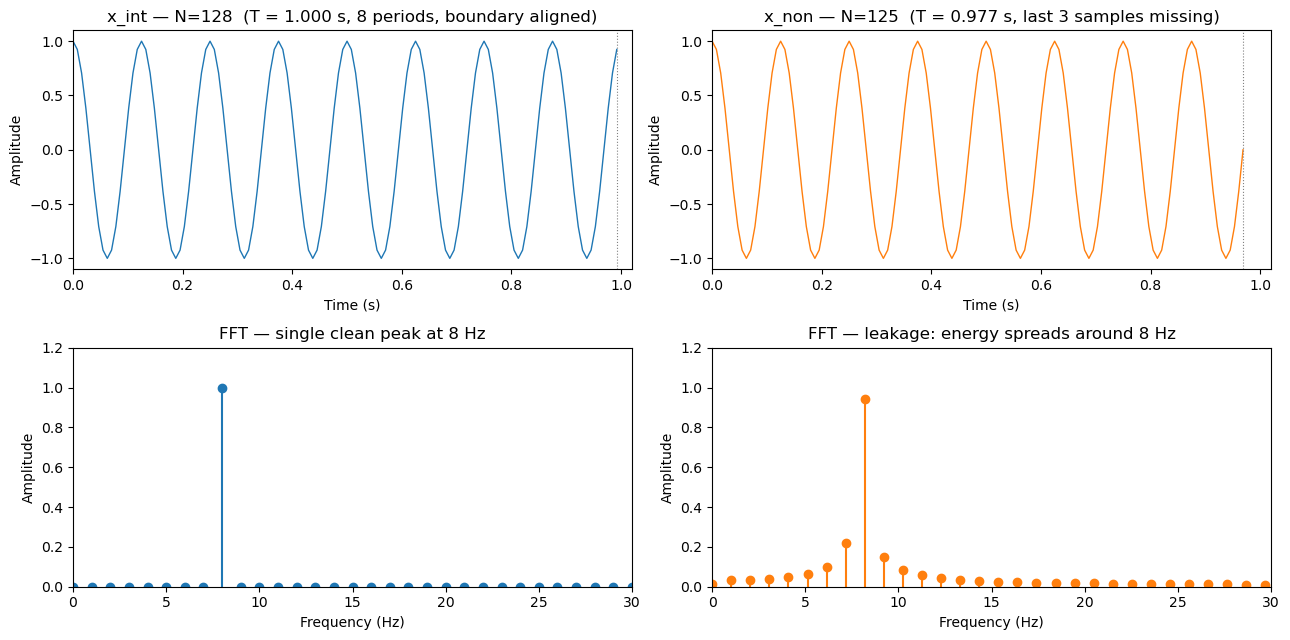

In [3]:
fs = 128
f0 = 8.0

# 정수 주기 (1.000 s = 정확히 8 주기)
N_int = 128
t_int = np.arange(N_int) / fs
x_int = np.cos(2 * np.pi * f0 * t_int)

# 비정수 주기 — 같은 신호인데 끝 3 샘플이 잘림 (T ≈ 0.977 s)
N_non = 125
t_non = np.arange(N_non) / fs
x_non = np.cos(2 * np.pi * f0 * t_non)

f_int_axis, A_int = fft(x_int, fs)
f_non_axis, A_non = fft(x_non, fs)

fig, axes = plt.subplots(2, 2, figsize=(13, 6.5))

# 상단: 시간 도메인 — 같은 신호, 길이만 다름
axes[0, 0].plot(t_int, x_int, 'C0', linewidth=1.0)
axes[0, 0].axvline(t_int[-1], color='gray', linestyle=':', linewidth=0.8)
axes[0, 0].set_title(f'x_int — N={N_int}  (T = {N_int/fs:.3f} s, 8 periods, boundary aligned)')
axes[0, 0].set_xlabel('Time (s)'); axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].set_xlim(0, 1.02)

axes[0, 1].plot(t_non, x_non, 'C1', linewidth=1.0)
axes[0, 1].axvline(t_non[-1], color='gray', linestyle=':', linewidth=0.8)
axes[0, 1].set_title(f'x_non — N={N_non}  (T = {N_non/fs:.3f} s, last 3 samples missing)')
axes[0, 1].set_xlabel('Time (s)'); axes[0, 1].set_ylabel('Amplitude')
axes[0, 1].set_xlim(0, 1.02)

# 하단: FFT
axes[1, 0].stem(f_int_axis, A_int, basefmt=' ', linefmt='C0-', markerfmt='C0o')
axes[1, 0].set_title('FFT — single clean peak at 8 Hz')
axes[1, 0].set_xlabel('Frequency (Hz)'); axes[1, 0].set_ylabel('Amplitude')
axes[1, 0].set_xlim(0, 30); axes[1, 0].set_ylim(0, 1.2)

axes[1, 1].stem(f_non_axis, A_non, basefmt=' ', linefmt='C1-', markerfmt='C1o')
axes[1, 1].set_title('FFT — leakage: energy spreads around 8 Hz')
axes[1, 1].set_xlabel('Frequency (Hz)'); axes[1, 1].set_ylabel('Amplitude')
axes[1, 1].set_xlim(0, 30); axes[1, 1].set_ylim(0, 1.2)

plt.tight_layout(); plt.show()

**관찰**: 두 신호는 **동일한 8 Hz 코사인**이지만, `x_non` 은 길이가 정수주기($N = 128 = 8 \cdot 16$) 에서 3 샘플 모자라 $N = 125$. 이 짧은 차이만으로 FFT 가 단일 피크에서 주변 여러 빈으로 에너지가 퍼지는 **누설** 을 보여준다. 경계 불연속이 누설의 본질임을 확인할 수 있다.

---

## 실습 2. 윈도우 함수 비교

비정수 주기 단일 톤에 Rectangular / Hann / Hamming / Blackman 네 가지 윈도우를 적용하여 **사이드 로브 감쇠량**을 한 그림으로 비교한다.

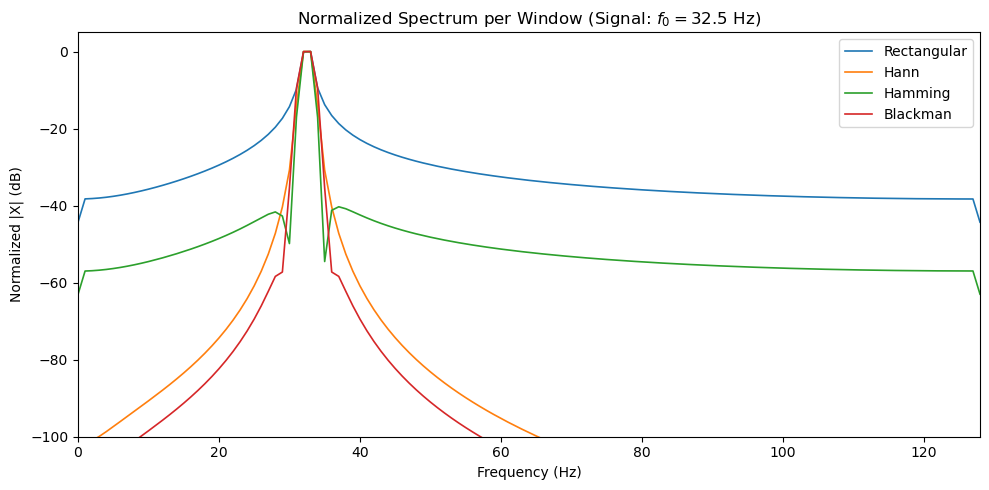

In [4]:
fs = 256
N = 256
t = np.arange(N) / fs
x = np.cos(2 * np.pi * 32.5 * t)   # 비정수 주기 → 누설 있음

windows = {
    'Rectangular': np.ones(N),
    'Hann':        np.hanning(N),
    'Hamming':     np.hamming(N),
    'Blackman':    np.blackman(N),
}
colors = ['C0', 'C1', 'C2', 'C3']

fig, ax = plt.subplots(figsize=(10, 5))
for (name, w), c in zip(windows.items(), colors):
    f, A = fft(x * w, fs)
    A_dB = 20 * np.log10(np.maximum(A / A.max(), 1e-12))
    ax.plot(f, A_dB, color=c, linewidth=1.2, label=name)

ax.set_title('Normalized Spectrum per Window (Signal: $f_0=32.5$ Hz)')
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Normalized |X| (dB)')
ax.set_xlim(0, fs/2); ax.set_ylim(-100, 5)
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

**관찰**: Rectangular 는 메인 로브가 좁지만 사이드 로브가 −13 dB 로 높아 누설이 넓게 퍼진다. Hann (−31 dB), Hamming (−41 dB), Blackman (−57 dB) 순으로 사이드 로브가 낮아지는 대신 메인 로브 폭이 넓어진다. 누설 감쇠와 주파수 분리 능력 사이에 트레이드오프가 있다.

---

## 실습 3. 윈도우의 효과 — 강한 피크 옆의 약한 성분 드러내기

비정수 주기 두 성분 $f_L = 8.5$ Hz (진폭 $A_L = 1.0$) + $f_S = 14.5$ Hz (진폭 $A_S = 0.05$, 진폭비 20:1). 사각 윈도우에서는 $f_L$ 의 사이드 로브가 $f_S$ 를 덮어 식별이 어렵고, Hann 윈도우를 적용하면 $f_S$ 피크가 단독 stem 으로 드러난다.

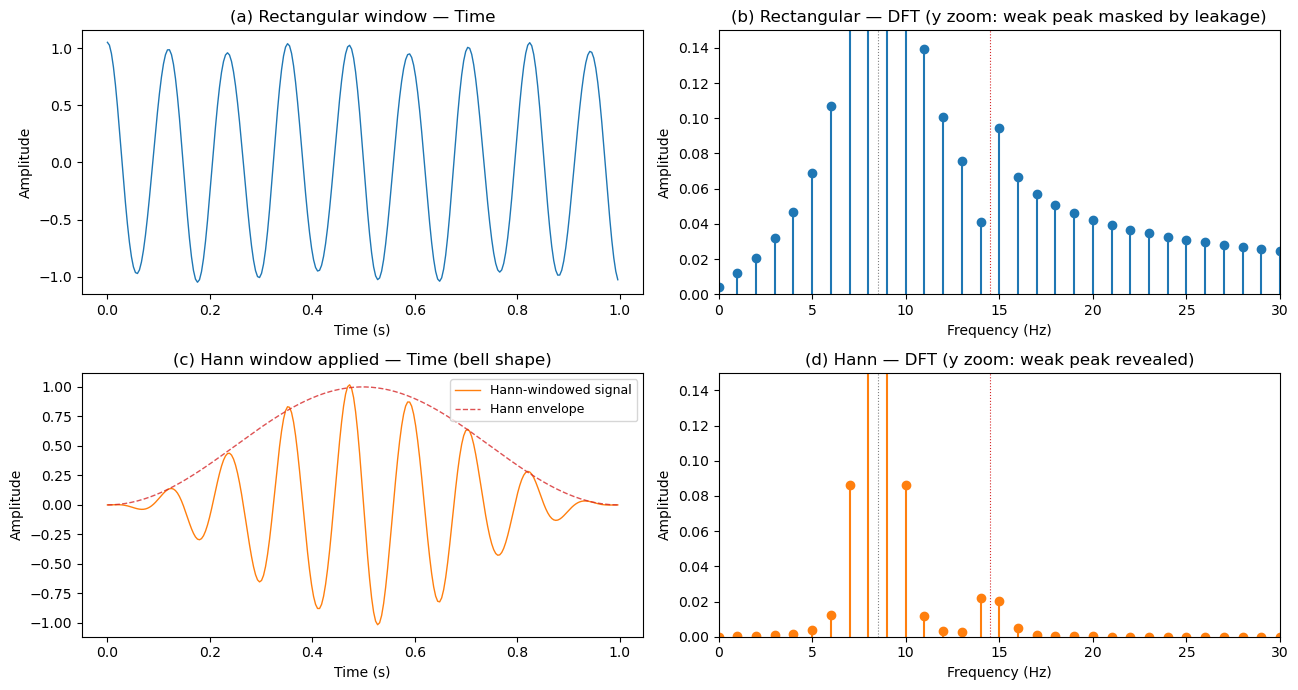

In [5]:
fs = 256
N  = 256
t  = np.arange(N) / fs
f_L, A_L = 8.5, 1.0
f_S, A_S = 14.5, 0.05
x = A_L * np.cos(2*np.pi*f_L*t) + A_S * np.cos(2*np.pi*f_S*t)

x_rect = x
w_hann = np.hanning(N)
x_hann = x * w_hann

f_r, A_r = fft(x_rect, fs)
f_h, A_h = fft(x_hann, fs)

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

# (a) 사각 time
axes[0, 0].plot(t, x_rect, 'C0', linewidth=1.0)
axes[0, 0].set_title('(a) Rectangular window — Time')
axes[0, 0].set_xlabel('Time (s)'); axes[0, 0].set_ylabel('Amplitude')

# (b) 사각 DFT — zoom for weak peak
axes[0, 1].stem(f_r, A_r, basefmt=' ', linefmt='C0-', markerfmt='C0o')
axes[0, 1].axvline(f_L, color='gray', linestyle=':', linewidth=0.8)
axes[0, 1].axvline(f_S, color='C3',   linestyle=':', linewidth=0.8)
axes[0, 1].set_title('(b) Rectangular — DFT (y zoom: weak peak masked by leakage)')
axes[0, 1].set_xlabel('Frequency (Hz)'); axes[0, 1].set_ylabel('Amplitude')
axes[0, 1].set_xlim(0, 30); axes[0, 1].set_ylim(0, 0.15)

# (c) Hann time
axes[1, 0].plot(t, x_hann, 'C1', linewidth=1.0, label='Hann-windowed signal')
axes[1, 0].plot(t, w_hann, 'C3--', linewidth=1.0, alpha=0.8, label='Hann envelope')
axes[1, 0].set_title('(c) Hann window applied — Time (bell shape)')
axes[1, 0].set_xlabel('Time (s)'); axes[1, 0].set_ylabel('Amplitude')
axes[1, 0].legend(fontsize=9, loc='upper right')

# (d) Hann DFT — same y zoom
axes[1, 1].stem(f_h, A_h, basefmt=' ', linefmt='C1-', markerfmt='C1o')
axes[1, 1].axvline(f_L, color='gray', linestyle=':', linewidth=0.8)
axes[1, 1].axvline(f_S, color='C3',   linestyle=':', linewidth=0.8)
axes[1, 1].set_title('(d) Hann — DFT (y zoom: weak peak revealed)')
axes[1, 1].set_xlabel('Frequency (Hz)'); axes[1, 1].set_ylabel('Amplitude')
axes[1, 1].set_xlim(0, 30); axes[1, 1].set_ylim(0, 0.15)

plt.tight_layout(); plt.show()

**관찰**:
- **(c)**: Hann 엔벨로프 (빨간 점선) 가 시간 축 양끝에서 0 으로 부드럽게 수렴 → 경계 불연속이 제거되어 (d) 에서 누설이 억제됨.
- (b), (d) 의 y 축은 [0, 0.15] 로 제한되어 $f_L = 8.5$ Hz 큰 피크는 잘려 보이지만, 관심 대상인 $f_S = 14.5$ Hz (진폭 0.05) 주변을 잘 볼 수 있다.
- 사각 윈도우에서는 $f_L$ 의 사이드 로브가 $f_S$ 위치 근처까지 넓게 퍼져 약한 피크를 **덮어버린다**.
- Hann 윈도우에서는 사이드 로브가 급격히 감쇠되어 $f_S$ 피크가 **단독 stem 으로 드러난다**.
- 이는 진폭비가 큰 두 성분을 함께 볼 때 Hann (또는 Blackman) 창이 필수임을 보여준다. 주파수가 매우 가까운 경우에는 반대로 Rectangular 가 유리한 트레이드오프가 있다.

---

## 실습 4. Leakage 해결 — 제로패딩

앞서 만든 `x_non` ($N=125$, 끝 3 샘플 잘림) 에 0 을 3 개 붙여 $N=128$ 로 복원한다. 세 결과를 나란히 본다.

1. **원본 `x_non` FFT** (제로패딩 없음) — bin 간격 $f_s/125$
2. **신호에 직접 0 을 붙이기** — `np.concatenate([x_non, zeros])` 로 확장한 배열을 `utils.fft` 에 넣음 (bin 간격 $f_s/128 = 1$ Hz)
3. **`utils.fft` 의 `n` 옵션 사용** — `utils.fft` 가 내부적으로 **`np.fft.rfft(x, n=128)` 의 `n` 인자**를 호출하여 NumPy 가 제공하는 제로패딩 기능을 활용한다 (별도로 `concatenate` 하지 않음). `utils.py` 에 해당 동작이 docstring 으로 정의되어 있다.

(2) 와 (3) 은 수치적으로 완전 동일하지만, (3) 이 **제공된 함수의 표준 인터페이스를 사용하는 권장 방식**이다.

제로패딩은 bin 간격을 보간하는 방법이지만, 0 으로 채운 구간은 실제 신호가 아니므로 **미세한 누설은 남는다**. 더 근본적인 해결책은 다음 실습에서 본다.

In [ ]:
# 앞서 만든 x_non 재사용 (N=125, 앞 실습)
fs = 128
N  = len(x_non)     # 125
N_target = 128      # 정수주기 길이로 복원

# (a) 원본 x_non FFT — bin 간격 fs/125, 8 Hz 는 bin 7.8125 (비정수)
f_a, A_a = fft(x_non, fs)

# (b) 신호에 직접 0 을 붙여서 FFT — bin 간격 1 Hz
x_padded = np.concatenate([x_non, np.zeros(N_target - N)])
f_b, A_b = fft(x_padded, fs)

# (c) utils.fft 의 n 옵션 사용 — 내부적으로 (b) 와 동일
f_c, A_c = fft(x_non, fs, n=N_target)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
axes[0].stem(f_a, A_a, basefmt=' ', linefmt='C0-', markerfmt='C0o')
axes[0].set_title(f'(a) Original x_non  N={N} (no padding)')
axes[1].stem(f_b, A_b, basefmt=' ', linefmt='C1-', markerfmt='C1o')
axes[1].set_title(f'(b) np.concatenate([x_non, zeros(3)])  N={N_target}')
axes[2].stem(f_c, A_c, basefmt=' ', linefmt='C2-', markerfmt='C2o')
axes[2].set_title(f'(c) utils.fft(x_non, fs, n={N_target})')

for ax in axes:
    ax.set_xlim(0, 30); ax.set_xlabel('Frequency (Hz)')
    ax.axvline(8, color='gray', linestyle=':', linewidth=0.8)
axes[0].set_ylabel('Amplitude')
plt.tight_layout(); plt.show()

**관찰**:
- (a) 원본: bin 간격이 $f_s/125 \approx 1.024$ Hz. 8 Hz 가 bin 에 정확히 맞지 않아 **누설이 남는다**.
- (b) 와 (c) 는 같은 결과 — (b) 는 배열을 명시적으로 확장해 FFT 에 넣고, (c) 는 `np.fft.rfft` 의 `n` 인자 기능을 `utils.fft` 를 통해 활용한다. (c) 가 더 간결하므로 실전에서는 이를 사용한다.
- bin 간격이 $f_s/128 = 1$ Hz 가 되면서 8 Hz 가 bin 8 에 정렬된다. 다만 0 으로 채운 영역은 실제 신호가 아니므로 **완전한 정수주기 데이터와는 달리** 미세한 누설이 남는다.

**중요**: 제로패딩은 bin 간격 보간이지 **관측 시간이 늘어나는 것은 아니다**. 주파수 해상도 (두 근접 성분을 분리할 능력) 는 오직 **실제 데이터 길이 T = N/fs** 로만 결정된다.

---

## 실습 5. Leakage 해결 — 충분히 긴 측정

제로패딩은 보간일 뿐 누설을 완전히 없애지는 못한다. **관측 시간을 실제로 늘리면** 누설이 남아있더라도 피크 주변 매우 좁은 구간에 국소화되어 **시각적으로 거의 문제가 되지 않는다** — 즉 길게 측정하면 신호가 정수주기인지 여부 자체를 따질 필요가 없어진다.

- 실습 1 의 8 Hz 단일 톤 — $N = 125$ vs $N = 10001$ (둘 다 **비정수주기**)
- 실습 3 의 8.5 + 14.5 Hz 합성 신호 — $N = 256$ vs $N = 10000$ (둘 다 **비정수주기**)

짧은 측정과 긴 측정의 스펙트럼을 비교한다.

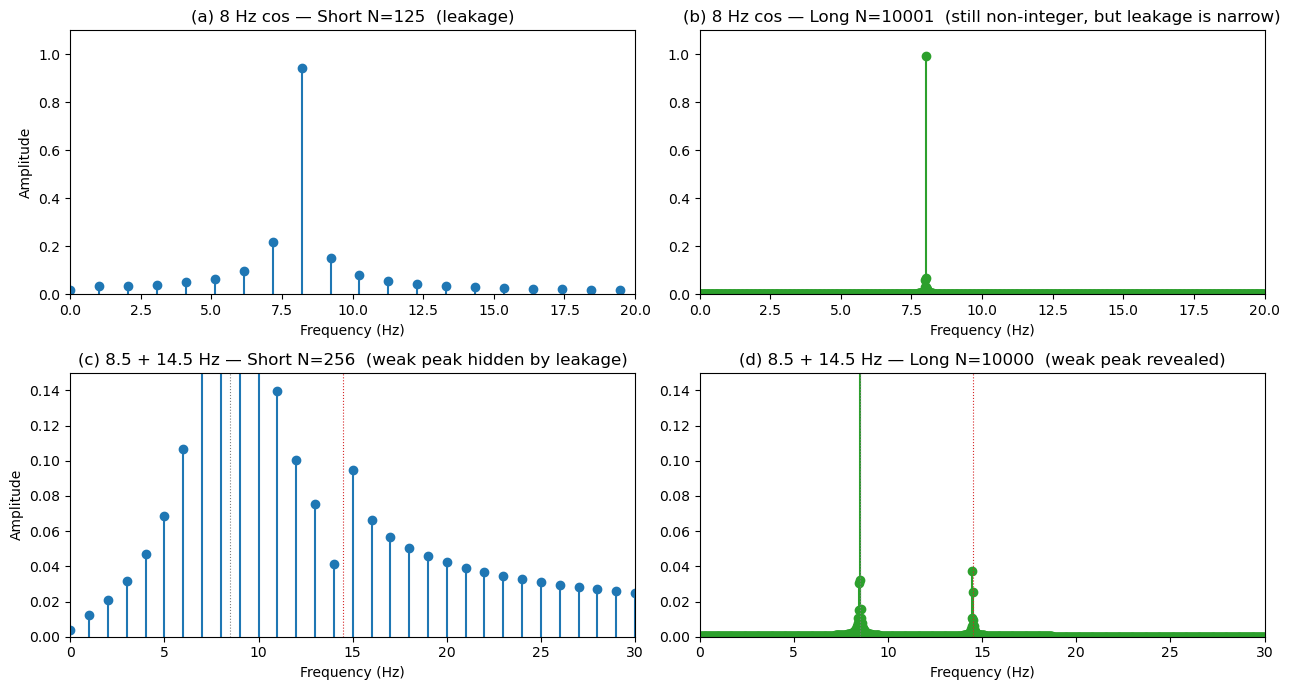

In [7]:
# 실습 1 의 8 Hz 단일 톤 — 짧게 vs 길게 (비정수주기 유지)
fs_1 = 128
N_1_short, N_1_long = 125, 10001  # 짧게: 8*125/128=7.81 비정수 / 길게: 8*10001/128=625.0625 여전히 비정수   
t_1s = np.arange(N_1_short) / fs_1
t_1l = np.arange(N_1_long)  / fs_1
x_1_short = np.cos(2 * np.pi * 8 * t_1s)
x_1_long  = np.cos(2 * np.pi * 8 * t_1l)
f_1s, A_1s = fft(x_1_short, fs_1)
f_1l, A_1l = fft(x_1_long,  fs_1)

# 실습 3 의 8.5 + 14.5 Hz 합성 신호 — 짧게 vs 길게 (비정수주기 유지)
fs_3 = 256
N_3_short, N_3_long = 256, 10000    # 256: 짧게 / 10000: 길게 (8.5*10000/256=332.03125, 비정수)
t_3s = np.arange(N_3_short) / fs_3
t_3l = np.arange(N_3_long)  / fs_3
x_3_short = np.cos(2*np.pi*8.5*t_3s) + 0.05 * np.cos(2*np.pi*14.5*t_3s)
x_3_long  = np.cos(2*np.pi*8.5*t_3l) + 0.05 * np.cos(2*np.pi*14.5*t_3l)
f_3s, A_3s = fft(x_3_short, fs_3)
f_3l, A_3l = fft(x_3_long,  fs_3)

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

# Row 0: 8 Hz 단일 톤
axes[0, 0].stem(f_1s, A_1s, basefmt=' ', linefmt='C0-', markerfmt='C0o')
axes[0, 0].set_title(f'(a) 8 Hz cos — Short N={N_1_short}  (leakage)')
axes[0, 0].set_xlim(0, 20); axes[0, 0].set_ylim(0, 1.1)
axes[0, 0].set_xlabel('Frequency (Hz)'); axes[0, 0].set_ylabel('Amplitude')

axes[0, 1].stem(f_1l, A_1l, basefmt=' ', linefmt='C2-', markerfmt='C2o')
axes[0, 1].set_title(f'(b) 8 Hz cos — Long N={N_1_long}  (still non-integer, but leakage is narrow)')
axes[0, 1].set_xlim(0, 20); axes[0, 1].set_ylim(0, 1.1)
axes[0, 1].set_xlabel('Frequency (Hz)')

# Row 1: 8.5 + 14.5 Hz 합성
axes[1, 0].stem(f_3s, A_3s, basefmt=' ', linefmt='C0-', markerfmt='C0o')
axes[1, 0].set_title(f'(c) 8.5 + 14.5 Hz — Short N={N_3_short}  (weak peak hidden by leakage)')
axes[1, 0].set_xlim(0, 30); axes[1, 0].set_ylim(0, 0.15)
axes[1, 0].set_xlabel('Frequency (Hz)'); axes[1, 0].set_ylabel('Amplitude')
axes[1, 0].axvline(8.5, color='gray', linestyle=':', linewidth=0.8)
axes[1, 0].axvline(14.5, color='C3',  linestyle=':', linewidth=0.8)

axes[1, 1].stem(f_3l, A_3l, basefmt=' ', linefmt='C2-', markerfmt='C2o')
axes[1, 1].set_title(f'(d) 8.5 + 14.5 Hz — Long N={N_3_long}  (weak peak revealed)')
axes[1, 1].set_xlim(0, 30); axes[1, 1].set_ylim(0, 0.15)
axes[1, 1].set_xlabel('Frequency (Hz)')
axes[1, 1].axvline(8.5, color='gray', linestyle=':', linewidth=0.8)
axes[1, 1].axvline(14.5, color='C3',  linestyle=':', linewidth=0.8)

plt.tight_layout(); plt.show()

**관찰**:
- (a), (c) 짧게 측정: 누설이 넓게 퍼져 특히 (c) 의 약한 14.5 Hz 피크가 강한 피크의 누설에 묻힌다.
- (b), (d) 길게 측정 (비정수주기는 동일): bin 간격 $\Delta f = f_s/N$ 이 크게 감소해 누설이 피크 주변 1~2 bin 에만 국소화된다. 결과적으로 **피크가 뚜렷하게 드러나고** (d) 에서는 약한 피크도 단독 식별이 가능.
- 실전에서는 **충분히 긴 측정이 누설 문제의 가장 단순한 해결책**이다. 관측 시간을 늘릴 수 없을 때 윈도우 함수(실습 2, 3) 또는 제로패딩(실습 4) 을 쓴다.

---

## 실습 6. dB 스케일 — 약한 성분 드러내기

진폭이 100 배 차이 나는 두 성분을 선형 스케일과 dB 스케일로 각각 본다. 결함 주파수 같은 미세한 성분을 탐지할 때 dB 가 왜 필수인지 확인한다.

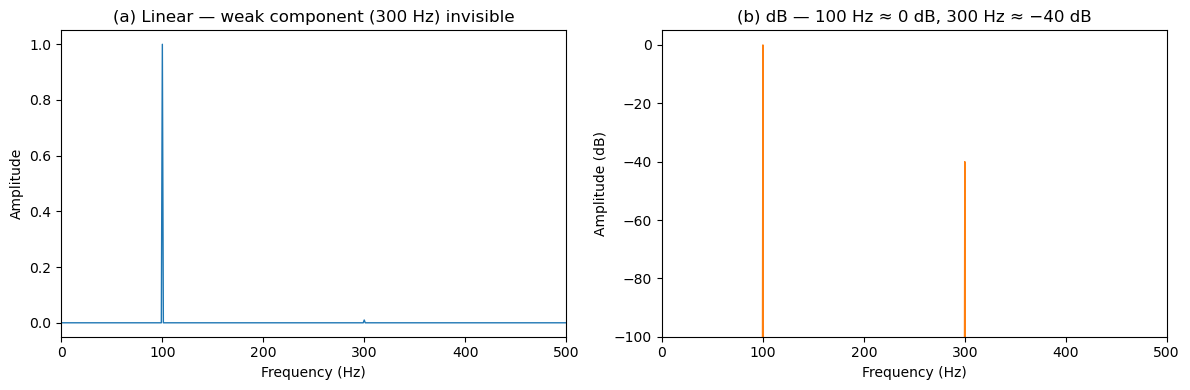

In [8]:
fs = 4096
N = 4096
t = np.arange(N) / fs
# 두 성분: 100 Hz(강, A=1.0), 300 Hz(약, A=0.01) → 비율 100:1
x = 1.0*np.sin(2*np.pi*100*t) + 0.01*np.sin(2*np.pi*300*t)

f, A = fft(x, fs)
A_dB = 20 * np.log10(np.maximum(A, 1e-12))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(f, A, 'C0-', linewidth=1.0)
axes[0].set_title('(a) Linear — weak component (300 Hz) invisible')
axes[0].set_xlim(0, 500); axes[0].set_xlabel('Frequency (Hz)'); axes[0].set_ylabel('Amplitude')

axes[1].plot(f, A_dB, 'C1-', linewidth=1.0)
axes[1].set_title('(b) dB — 100 Hz ≈ 0 dB, 300 Hz ≈ −40 dB')
axes[1].set_xlim(0, 500); axes[1].set_ylim(-100, 5)
axes[1].set_xlabel('Frequency (Hz)'); axes[1].set_ylabel('Amplitude (dB)')
plt.tight_layout(); plt.show()

**관찰**: 선형 스케일에서는 300 Hz 성분(진폭 0.01)이 눈으로 보이지 않지만, dB 스케일에서는 −40 dB 피크로 선명히 드러난다. 결함 주파수 같은 작은 성분을 탐지할 때 dB는 필수다.

---

## 실습 7. Welch PSD — 세그먼트 평균과 선형/dB 표시

단일 FFT (Periodogram) vs Welch PSD 의 잡음 바닥 차이를 선형과 dB 두 스케일에서 비교한다. 세그먼트 평균이 분산을 어떻게 줄이는지, 그리고 PSD 값이 어느 크기 범위에 있는지 함께 확인.

**주의**: periodogram 과 Welch 는 정규화 정의가 달라 y 축 절대값이 다를 수 있다. 비교 대상은 **피크 위 noise floor 의 상대 높이**와 **분산(들쭉날쭉한 정도)** 이다.

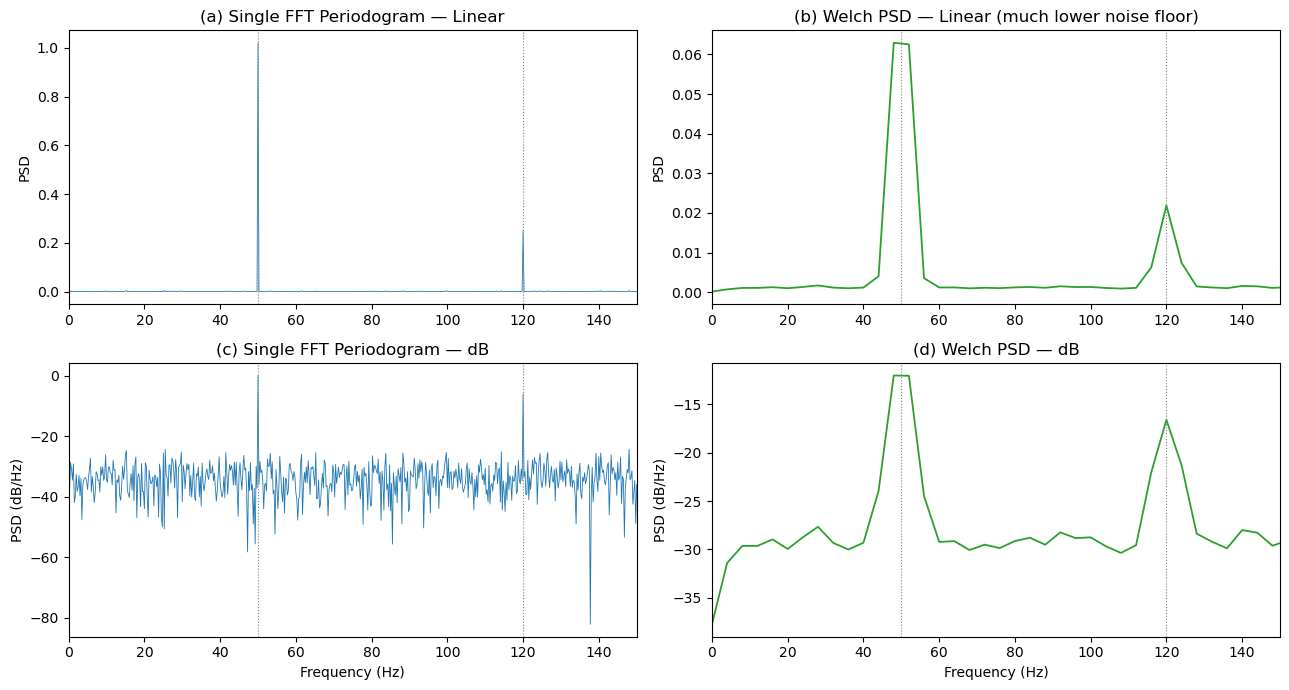

In [9]:
np.random.seed(0)
fs = 1024
duration = 4.0
N = int(fs * duration)
t = np.arange(N) / fs

x = (np.sin(2*np.pi*50*t) + 0.5*np.sin(2*np.pi*120*t)
     + 0.8*np.random.randn(N))

# 단일 FFT → PSD
X = np.fft.rfft(x)
f_fft = np.fft.rfftfreq(N, 1/fs)
psd_fft = (np.abs(X)**2) / (N * fs)
psd_fft_dB = 10 * np.log10(np.maximum(psd_fft, 1e-12))

# Welch PSD
f_w, psd_w = signal.welch(x, fs=fs, nperseg=256, noverlap=128, window='hann')
psd_w_dB = 10 * np.log10(np.maximum(psd_w, 1e-12))

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

# 상단: Linear (각 y축 별도 — PSD 값 자체가 FFT/Welch 간 다름)
axes[0, 0].plot(f_fft, psd_fft, 'C0-', linewidth=0.6)
axes[0, 0].set_title('(a) Single FFT Periodogram — Linear')
axes[0, 0].set_ylabel('PSD')

axes[0, 1].plot(f_w, psd_w, 'C2-', linewidth=1.3)
axes[0, 1].set_title('(b) Welch PSD — Linear (much lower noise floor)')
axes[0, 1].set_ylabel('PSD')

# 하단: dB (y축 공유 — 같은 단위)
axes[1, 0].plot(f_fft, psd_fft_dB, 'C0-', linewidth=0.6)
axes[1, 0].set_title('(c) Single FFT Periodogram — dB')
axes[1, 0].set_ylabel('PSD (dB/Hz)'); axes[1, 0].set_xlabel('Frequency (Hz)')

axes[1, 1].plot(f_w, psd_w_dB, 'C2-', linewidth=1.3)
axes[1, 1].set_title('(d) Welch PSD — dB')
axes[1, 1].set_ylabel('PSD (dB/Hz)'); axes[1, 1].set_xlabel('Frequency (Hz)')

for ax in axes.ravel():
    ax.set_xlim(0, 150)
    ax.axvline(50,  color='gray', linestyle=':', linewidth=0.8)
    ax.axvline(120, color='gray', linestyle=':', linewidth=0.8)
plt.tight_layout(); plt.show()

**관찰**:
- 두 방법 모두 50/120 Hz 피크가 있지만, 단일 FFT 는 Periodogram 이라 잡음 바닥이 들쭉날쭉하다.
- Welch PSD 는 세그먼트 평균으로 분산이 줄어 잡음 바닥이 매끄러워져 피크가 선명하다 (선형·dB 모두).
- 선형 스케일에서는 50 Hz 강한 피크에 눈이 쏠리지만, dB 스케일에서는 120 Hz 약한 피크도 동등한 가시성을 얻는다. `nperseg` 를 줄이면 분산은 더 줄지만 주파수 해상도가 낮아져 피크 폭이 넓어진다.

**주의**: periodogram 과 Welch 는 정규화 정의가 달라 y 축 절대값이 다를 수 있다. 비교 대상은 **피크 위 noise floor 의 상대 높이**와 **분산(들쭉날쭉한 정도)** 이다.

---

## 실습 8. 실제 진동 데이터 — 지금까지의 도구 종합

`data_normal.csv` 에 지금까지의 도구를 종합 적용한다. 선형 FFT · dB FFT · Welch PSD 세 가지 표현에서 지배 공진 대역과 저주파 회전 성분이 어떻게 드러나는지 비교한다.

Number of Samples N = 120000,  duration = 10.00 s
Top-5 peaks:
  f =  1036.1 Hz   A = 0.0555   (-25.1 dB)
  f =  1006.2 Hz   A = 0.0467   (-26.6 dB)
  f =  1096.0 Hz   A = 0.0211   (-33.5 dB)
  f =    90.0 Hz   A = 0.0204   (-33.8 dB)
  f =  2102.1 Hz   A = 0.0195   (-34.2 dB)


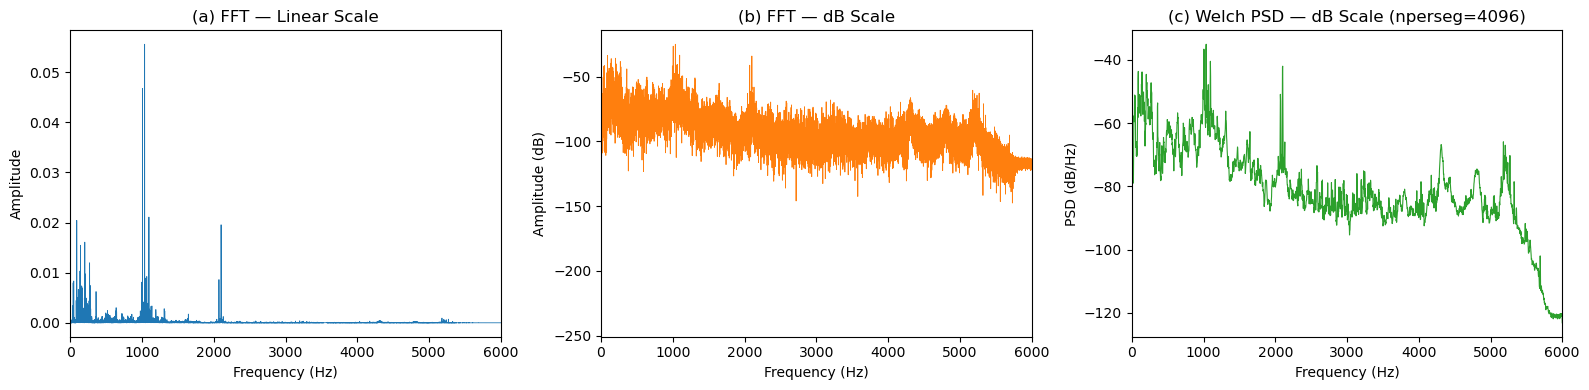

In [10]:
import pandas as pd

fs = 12000
data = np.array(pd.read_csv('./data/data_normal.csv'))
x = data[:, 1]
x = x - np.mean(x)
N = len(x)
t = np.arange(N) / fs
print(f'Number of Samples N = {N},  duration = {N/fs:.2f} s')

f, A = fft(x, fs)
A_dB = 20 * np.log10(np.maximum(A, 1e-12))

# Welch PSD
f_w, psd_w = signal.welch(x, fs=fs, nperseg=4096, noverlap=2048, window='hann')
psd_w_dB = 10 * np.log10(np.maximum(psd_w, 1e-20))

# 상위 5개 피크 출력
top_idx = np.argsort(A)[::-1][:5]
print('Top-5 peaks:')
for i in top_idx:
    print(f'  f = {f[i]:7.1f} Hz   A = {A[i]:.4f}   ({A_dB[i]:+.1f} dB)')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(f, A, 'C0-', linewidth=0.6)
axes[0].set_title('(a) FFT — Linear Scale')
axes[0].set_xlabel('Frequency (Hz)'); axes[0].set_ylabel('Amplitude')
axes[0].set_xlim(0, fs/2)

axes[1].plot(f, A_dB, 'C1-', linewidth=0.6)
axes[1].set_title('(b) FFT — dB Scale')
axes[1].set_xlabel('Frequency (Hz)'); axes[1].set_ylabel('Amplitude (dB)')
axes[1].set_xlim(0, fs/2)

axes[2].plot(f_w, psd_w_dB, 'C2-', linewidth=0.8)
axes[2].set_title('(c) Welch PSD — dB Scale (nperseg=4096)')
axes[2].set_xlabel('Frequency (Hz)'); axes[2].set_ylabel('PSD (dB/Hz)')
axes[2].set_xlim(0, fs/2)

plt.tight_layout(); plt.show()

**관찰**: 선형 스케일에서 지배적인 피크는 **1006/1036/1096 Hz 대역의 기계 공진** (진폭 약 0.04–0.06) 과 **2102 Hz 부근 추가 공진** 이다. 반면 **저주파 (90, 142, 202 Hz 등) 회전·하중 관련 성분은 선형 스케일에서는 거의 묻혀** 있다가 dB 스케일에서 약 −34 dB 부근 피크로 선명히 드러난다. 약한 저주파 성분은 강한 공진 대역과 진폭비가 10배 이상이라 dB 가 아니면 보이지 않는다.

---

## 정리

본 노트북에서는 스펙트럼 분석의 핵심 실무 도구를 익혔다.

- **누설(leakage)**: 관측 시간이 신호 주기의 정수배가 아닐 때 발생 (실습 1)
- **해결책**: 윈도우 함수 (실습 2-3) → 제로패딩 보간 (실습 4) → **충분히 긴 측정** (실습 5, 근본 해결)
- **dB 스케일** (실습 6): 수십 dB 차이 나는 성분을 함께 시각화
- **Welch PSD** (실습 7): 세그먼트 평균으로 분산 감소 + 잡음 바닥 낮춤
- **실제 데이터 종합** (실습 8): 선형/dB/Welch 도구를 한 신호에 적용
